# yfinance Library Assignment  

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [2]:
def download_historical_data(symbol, start_date, end_date, timeframe='1d'):
    """
    Fetch historical price data using Yahoo Finance.

    Parameters:
        symbol (str): Ticker symbol (e.g., 'RELIANCE.NS')
        start_date (str): Start date in 'YYYY-MM-DD' format
        end_date (str): End date in 'YYYY-MM-DD' format
        timeframe (str): Data frequency - '1d', '1wk', '1mo' (default '1d')

    Returns:
        pd.DataFrame: DataFrame containing the fetched historical data
    """
    df = yf.download(symbol, start=start_date, end=end_date, interval=timeframe)
    df.dropna(inplace=True)
    return df

### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [3]:
def plot_closing_prices(dataframes, labels, title='Stock Closing Prices'):
    """
    Plot closing prices for one or more stocks.

    Parameters:
        dataframes (list): List of DataFrames with stock data
        labels (list): List of stock labels/names
        title (str): Title of the plot
    """
    plt.figure(figsize=(14, 6))
    for df, label in zip(dataframes, labels):
        plt.plot(df.index, df['Close'], label=label)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price (INR)')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Run the functions

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

/tmp/ipykernel_7580/3642405397.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=timeframe)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_7580/3642405397.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=timeframe)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_7580/3642405397.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=timeframe)
[*********************100%***********************]  1 of 1 completed


MRF Data Shape: (2713, 5)
BSE Data Shape: (1461, 5)
Tata Steel Data Shape: (2713, 5)


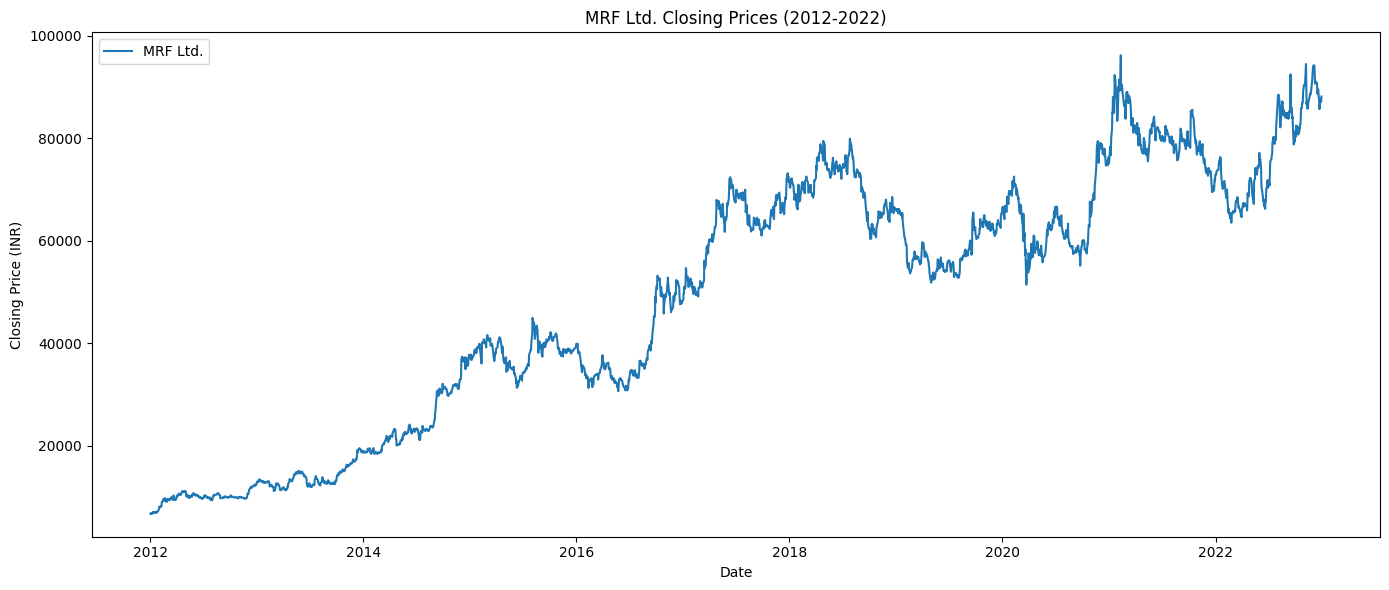

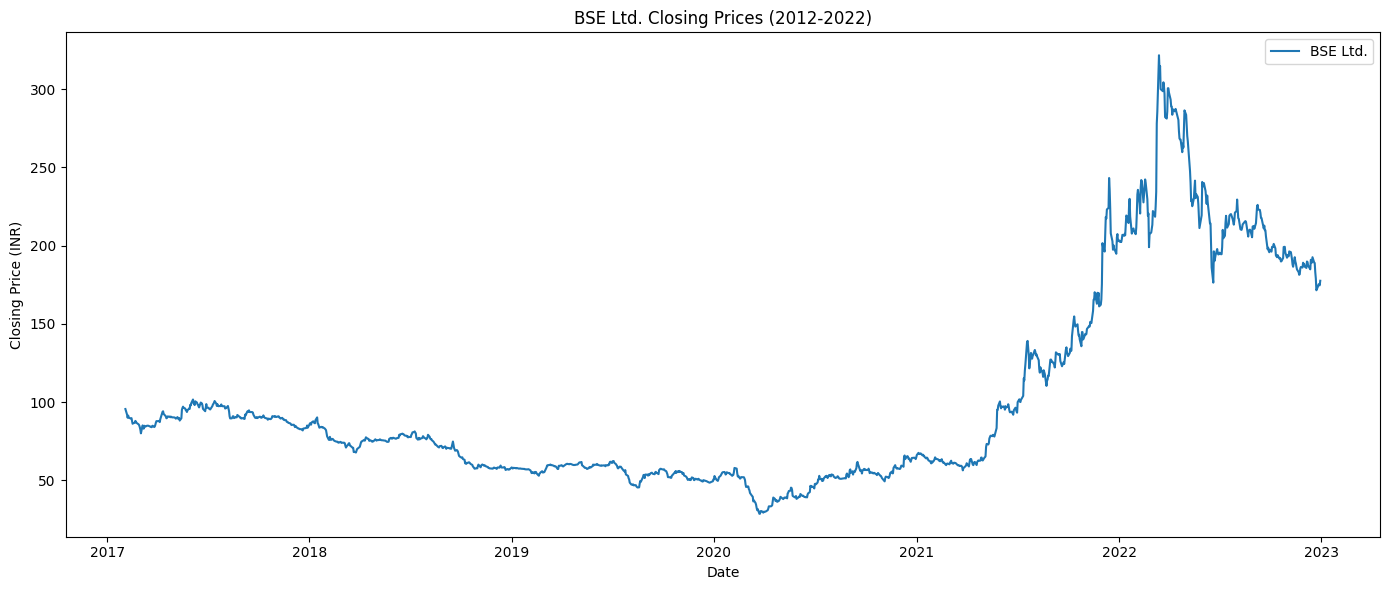

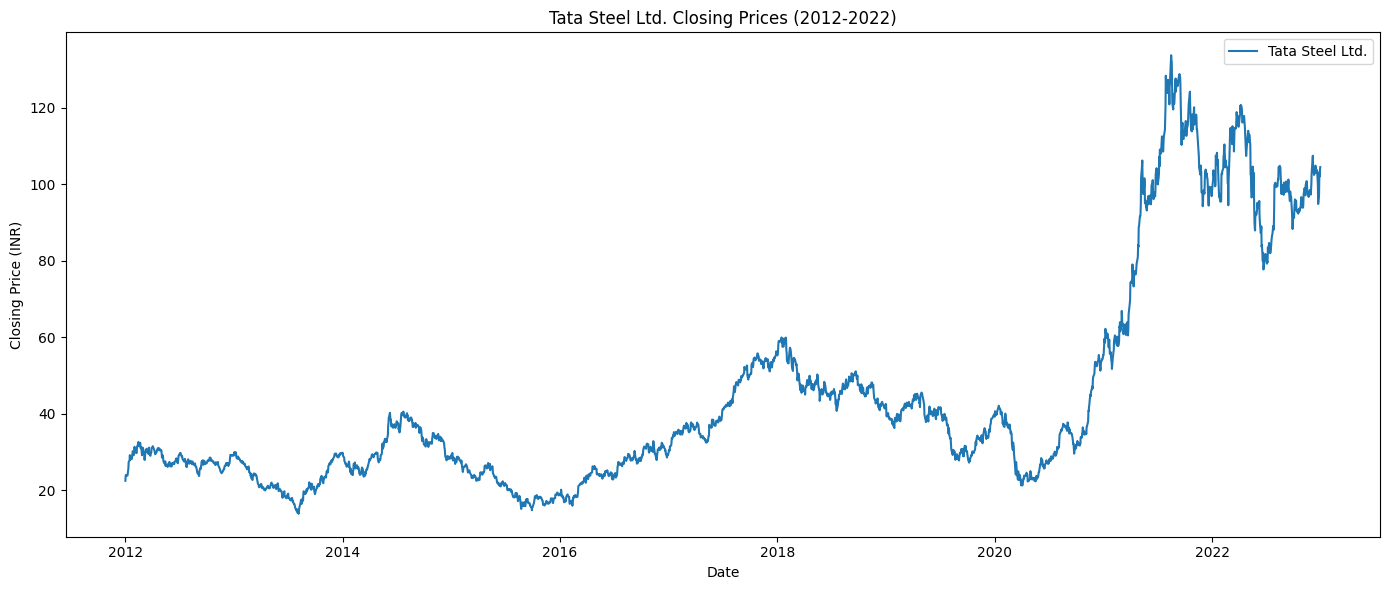

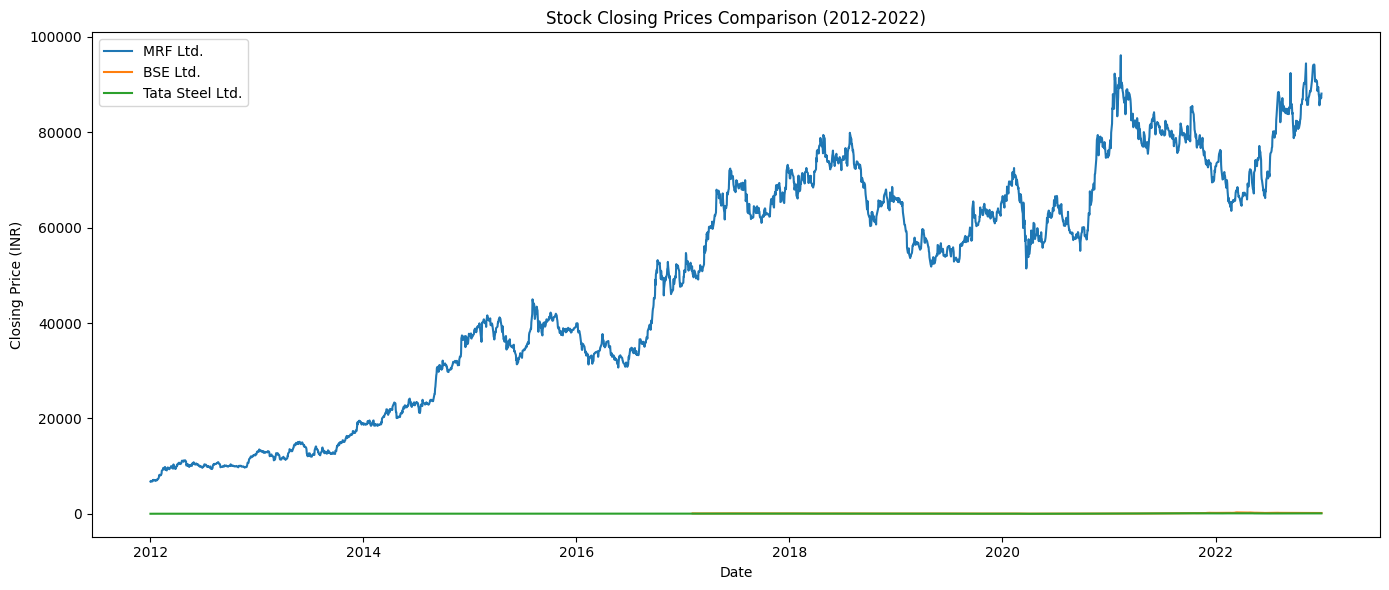

In [4]:
# Stock ticker symbols for NSE (National Stock Exchange of India)
mrf_symbol = 'MRF.NS'
bse_symbol = 'BSE.NS'
tata_steel_symbol = 'TATASTEEL.NS'

start_date = '2012-01-01'
end_date = '2022-12-31'

# Download historical data
mrf_data = download_historical_data(mrf_symbol, start_date, end_date)
bse_data = download_historical_data(bse_symbol, start_date, end_date)
tata_steel_data = download_historical_data(tata_steel_symbol, start_date, end_date)

print('MRF Data Shape:', mrf_data.shape)
print('BSE Data Shape:', bse_data.shape)
print('Tata Steel Data Shape:', tata_steel_data.shape)

# Plot each stock separately
plot_closing_prices([mrf_data], ['MRF Ltd.'], title='MRF Ltd. Closing Prices (2012-2022)')
plot_closing_prices([bse_data], ['BSE Ltd.'], title='BSE Ltd. Closing Prices (2012-2022)')
plot_closing_prices([tata_steel_data], ['Tata Steel Ltd.'], title='Tata Steel Ltd. Closing Prices (2012-2022)')

# Plot all three stocks on the same graph
plot_closing_prices(
    [mrf_data, bse_data, tata_steel_data],
    ['MRF Ltd.', 'BSE Ltd.', 'Tata Steel Ltd.'],
    title='Stock Closing Prices Comparison (2012-2022)'
)

### Technical Analysis

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

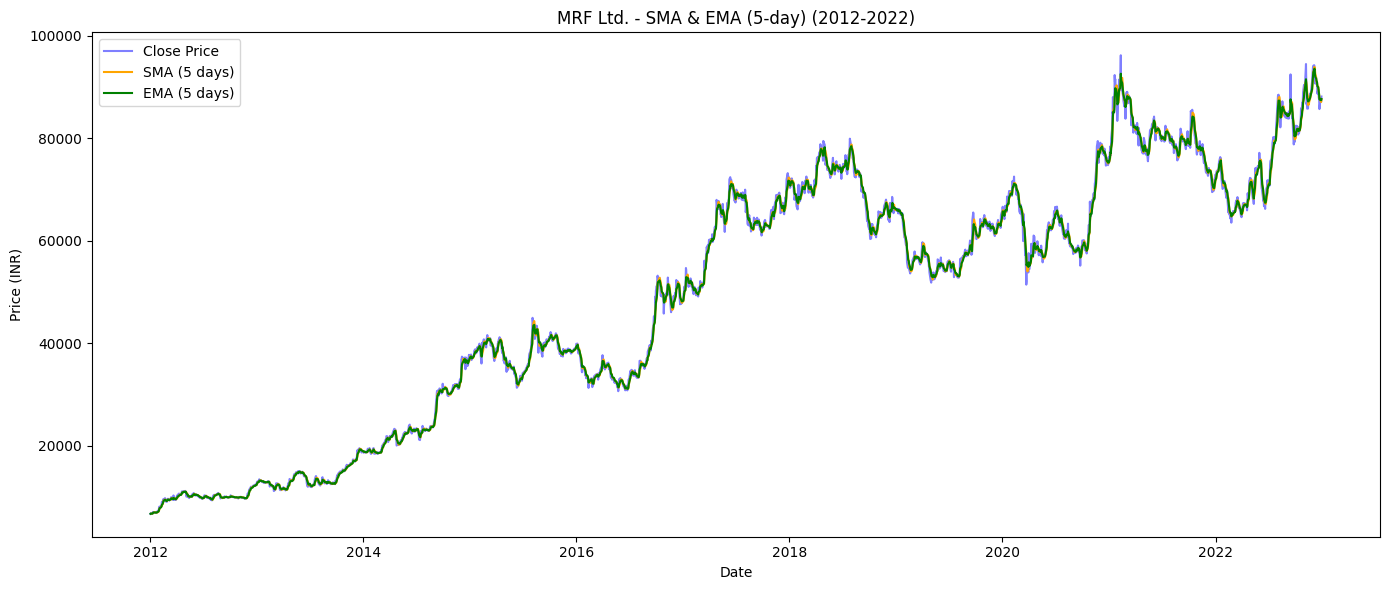

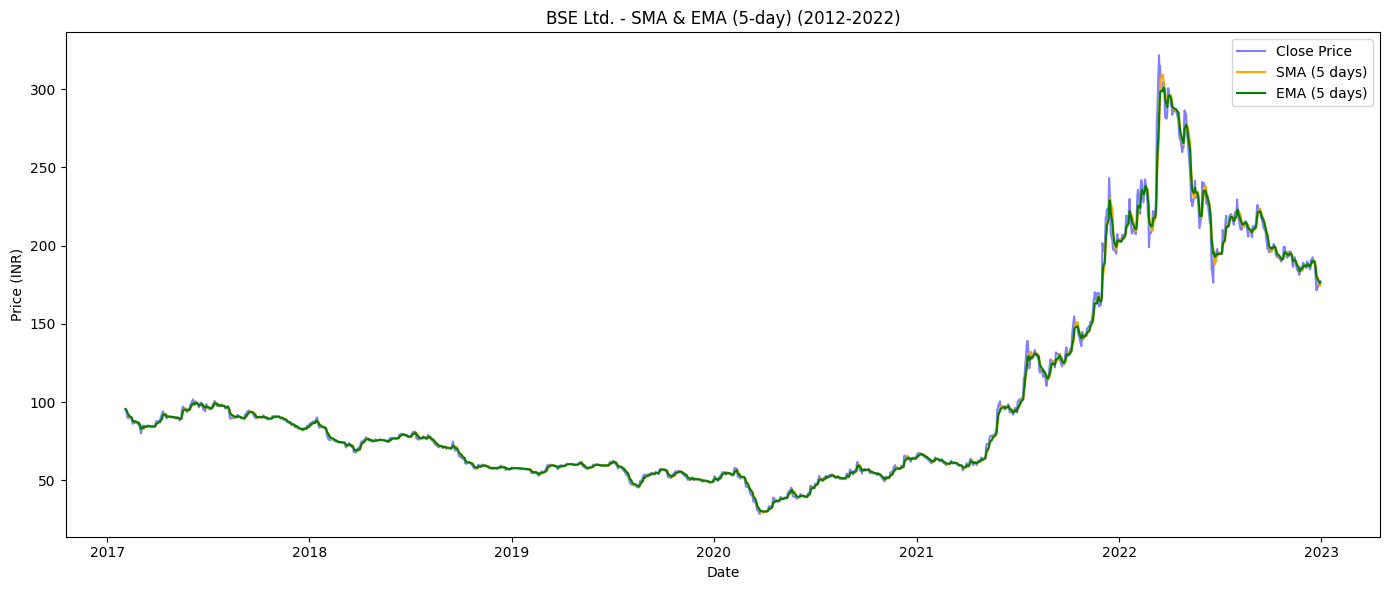

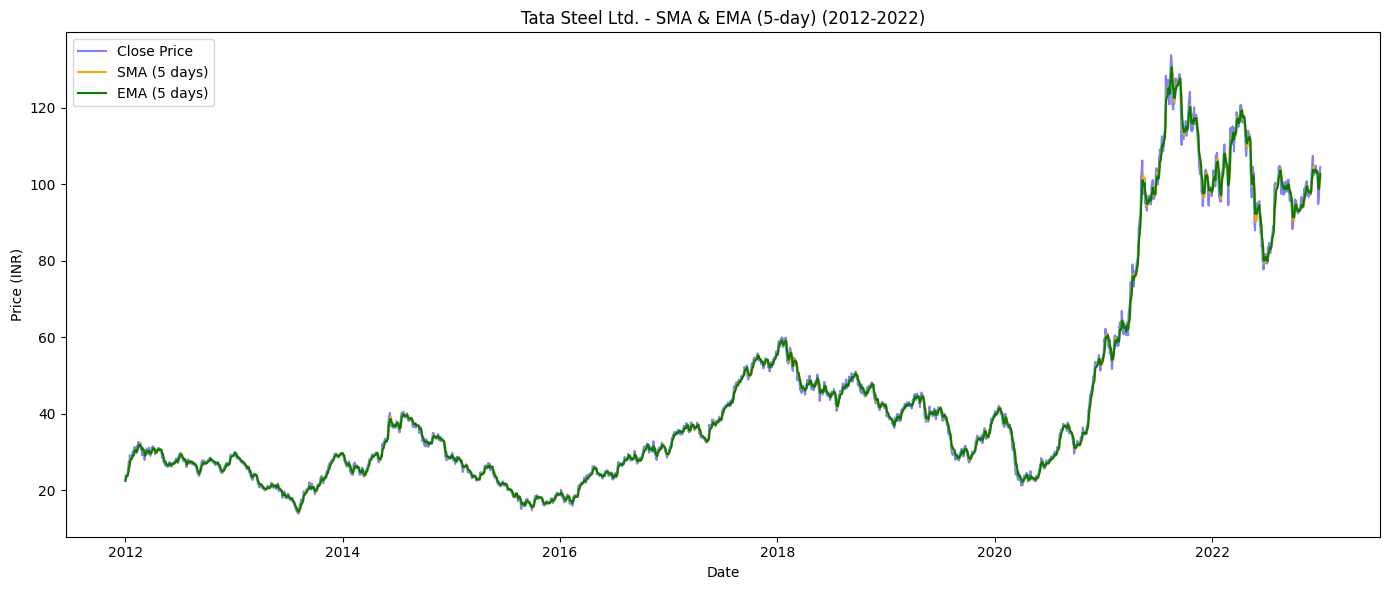

In [5]:
def plot_sma_ema(df, label, window=5):
    """
    Plot closing price with SMA and EMA on the same graph.

    Parameters:
        df (pd.DataFrame): Stock data DataFrame
        label (str): Stock name for the title
        window (int): Period for SMA and EMA calculation (default 5)
    """
    sma = df['Close'].rolling(window=window).mean()
    ema = df['Close'].ewm(span=window, adjust=False).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5, color='blue')
    plt.plot(df.index, sma, label=f'SMA ({window} days)', color='orange', linewidth=1.5)
    plt.plot(df.index, ema, label=f'EMA ({window} days)', color='green', linewidth=1.5)
    plt.title(f'{label} - SMA & EMA ({window}-day) (2012-2022)')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot SMA and EMA for each stock
plot_sma_ema(mrf_data, 'MRF Ltd.')
plot_sma_ema(bse_data, 'BSE Ltd.')
plot_sma_ema(tata_steel_data, 'Tata Steel Ltd.')

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

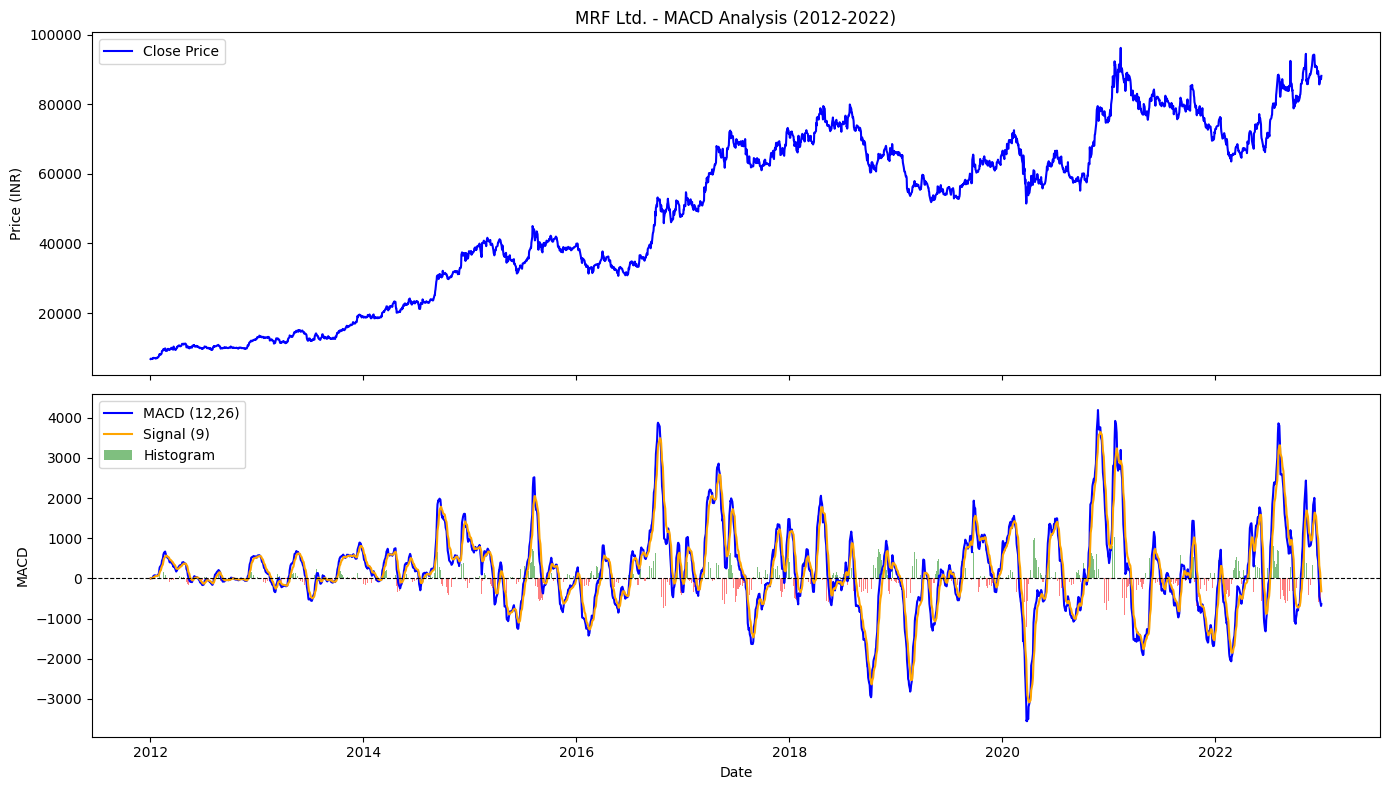

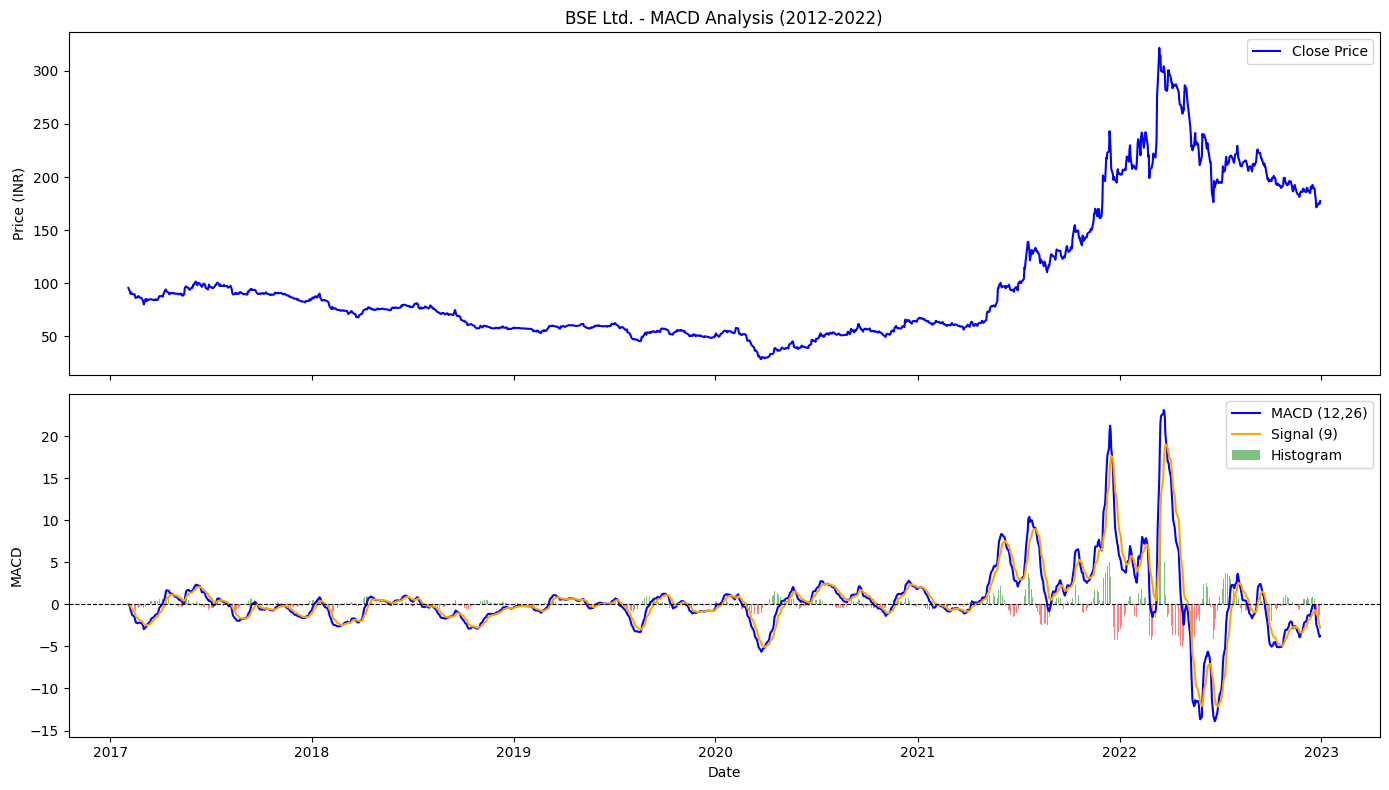

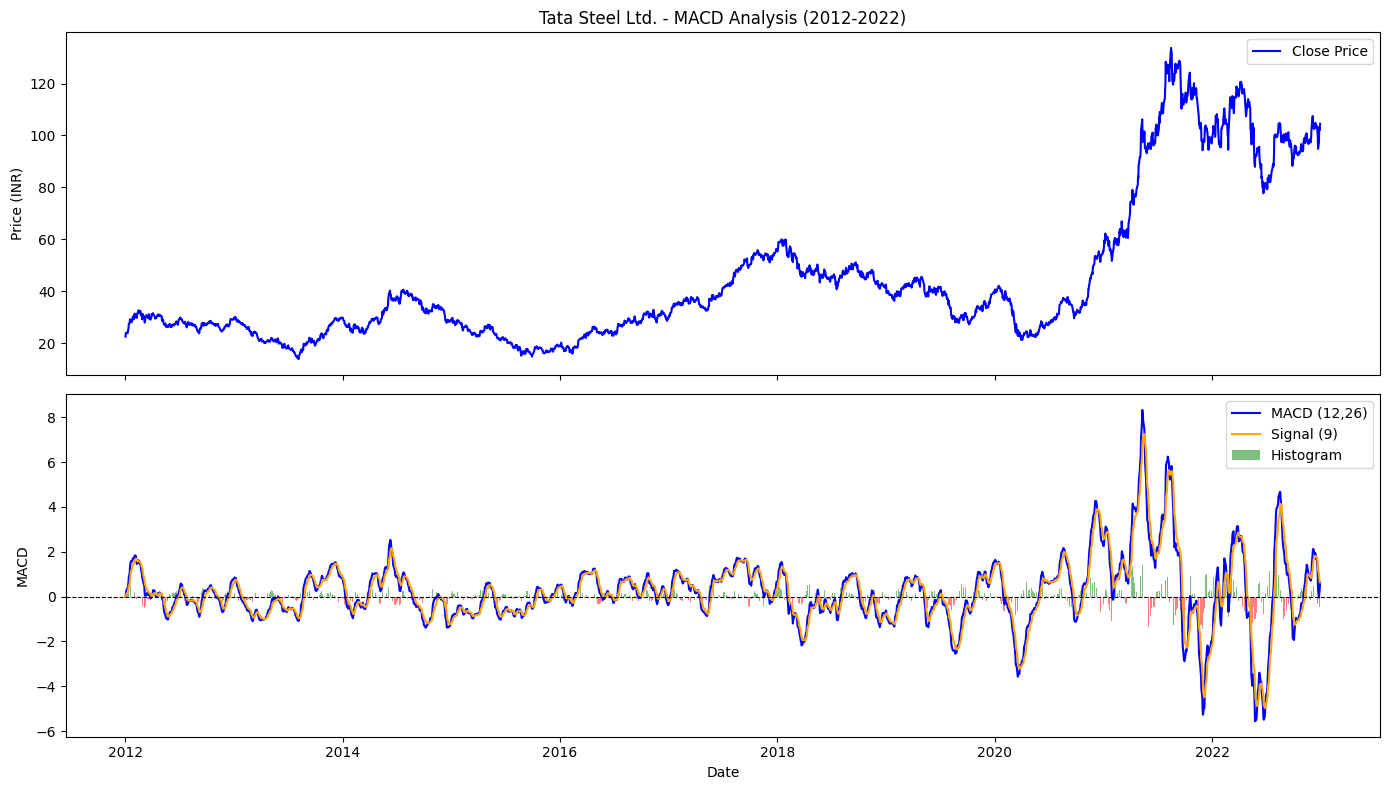

In [7]:
def plot_macd(df, label, fast=12, slow=26, signal=9):
    """
    Plot MACD and Signal line for a stock.

    Parameters:
        df (pd.DataFrame): Stock data DataFrame
        label (str): Stock name for the title
        fast (int): Fast EMA period (default 12)
        slow (int): Slow EMA period (default 26)
        signal (int): Signal line EMA period (default 9)
    """
    close = df['Close'].squeeze().astype(float)
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    hist_values = histogram.values.astype(float)
    colors = ['green' if v >= 0 else 'red' for v in hist_values]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(df.index, close, label='Close Price', color='blue')
    ax1.set_title(f'{label} - MACD Analysis (2012-2022)')
    ax1.set_ylabel('Price (INR)')
    ax1.legend()

    ax2.plot(df.index, macd_line, label=f'MACD ({fast},{slow})', color='blue', linewidth=1.5)
    ax2.plot(df.index, signal_line, label=f'Signal ({signal})', color='orange', linewidth=1.5)
    ax2.bar(df.index, histogram, label='Histogram', color=colors, alpha=0.5)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('MACD')
    ax2.set_xlabel('Date')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot MACD for each stock
plot_macd(mrf_data, 'MRF Ltd.')
plot_macd(bse_data, 'BSE Ltd.')
plot_macd(tata_steel_data, 'Tata Steel Ltd.')

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days
   - Also show the overbought and oversold regions
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

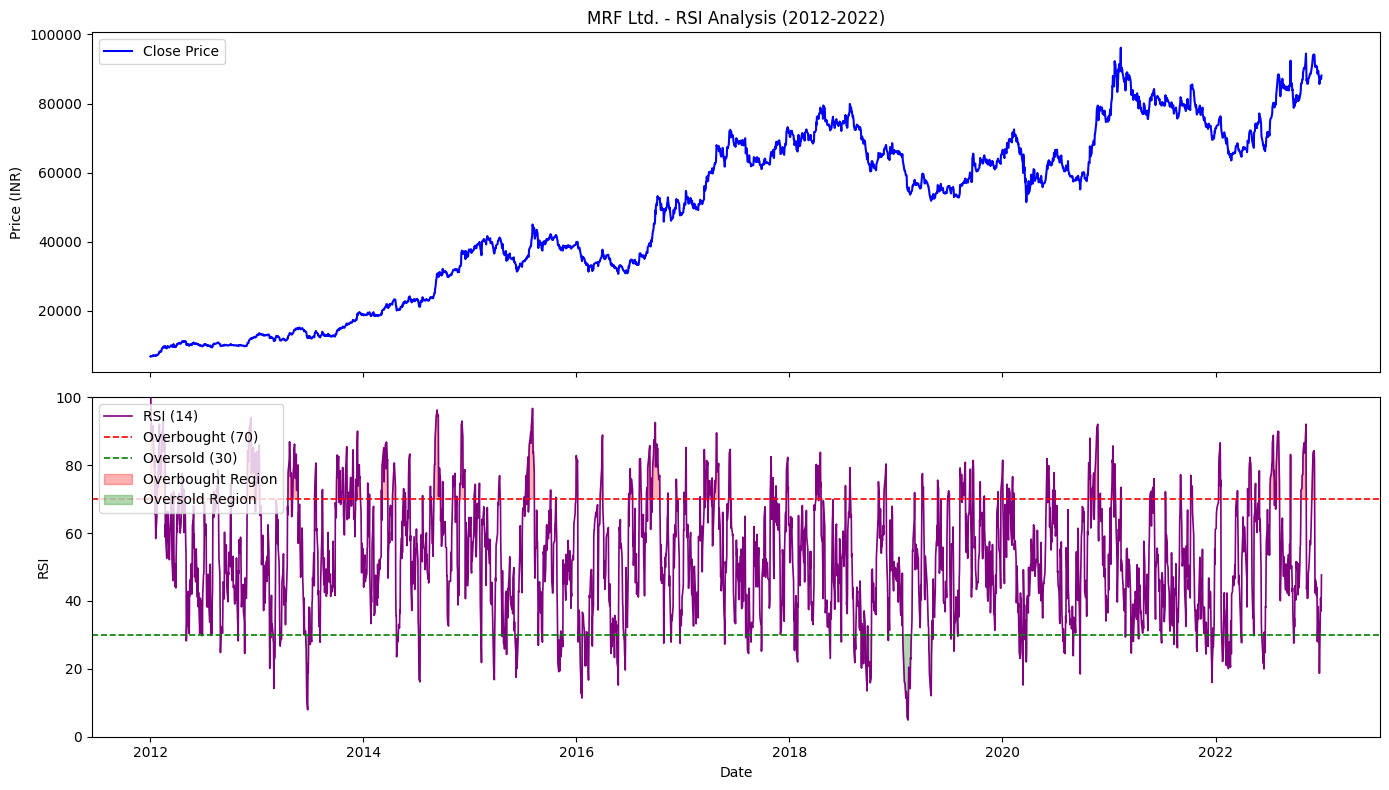

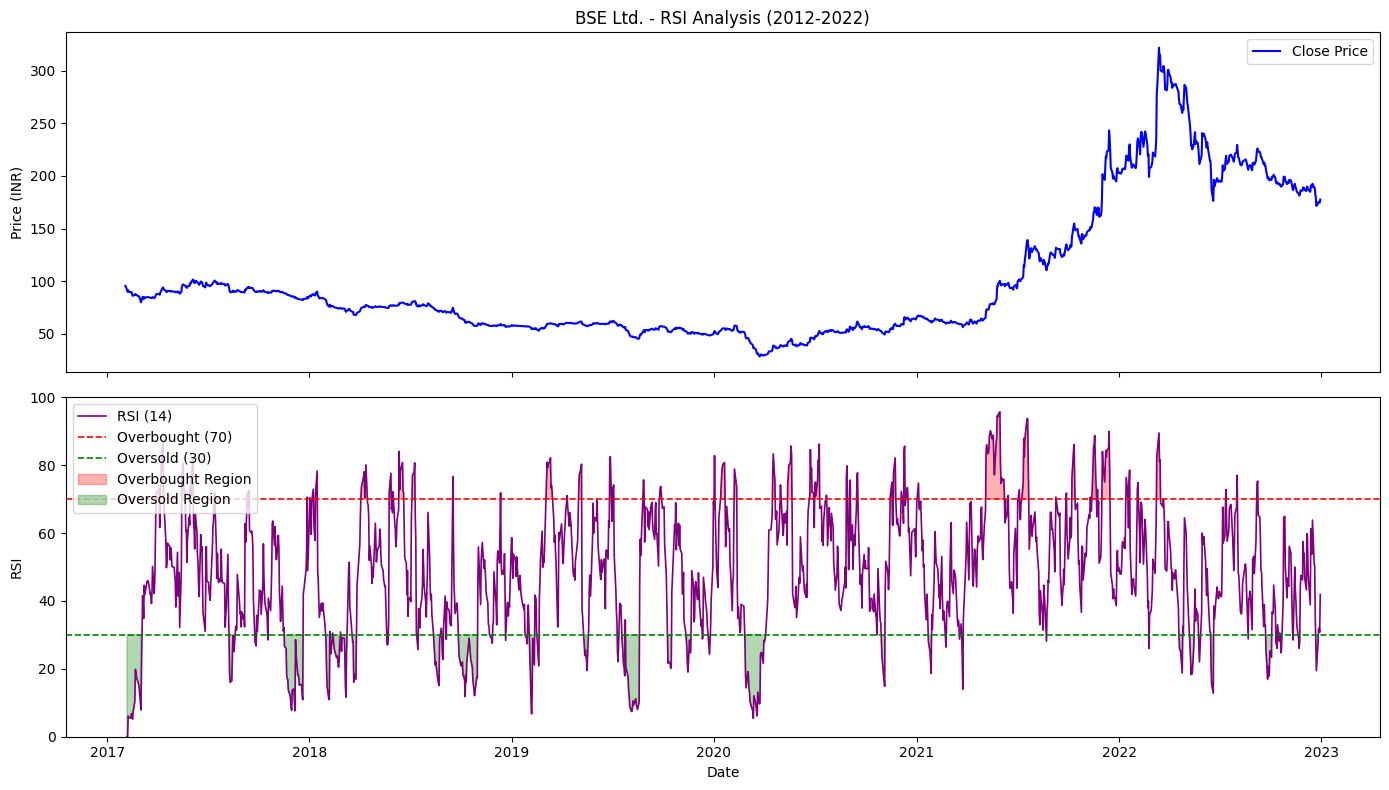

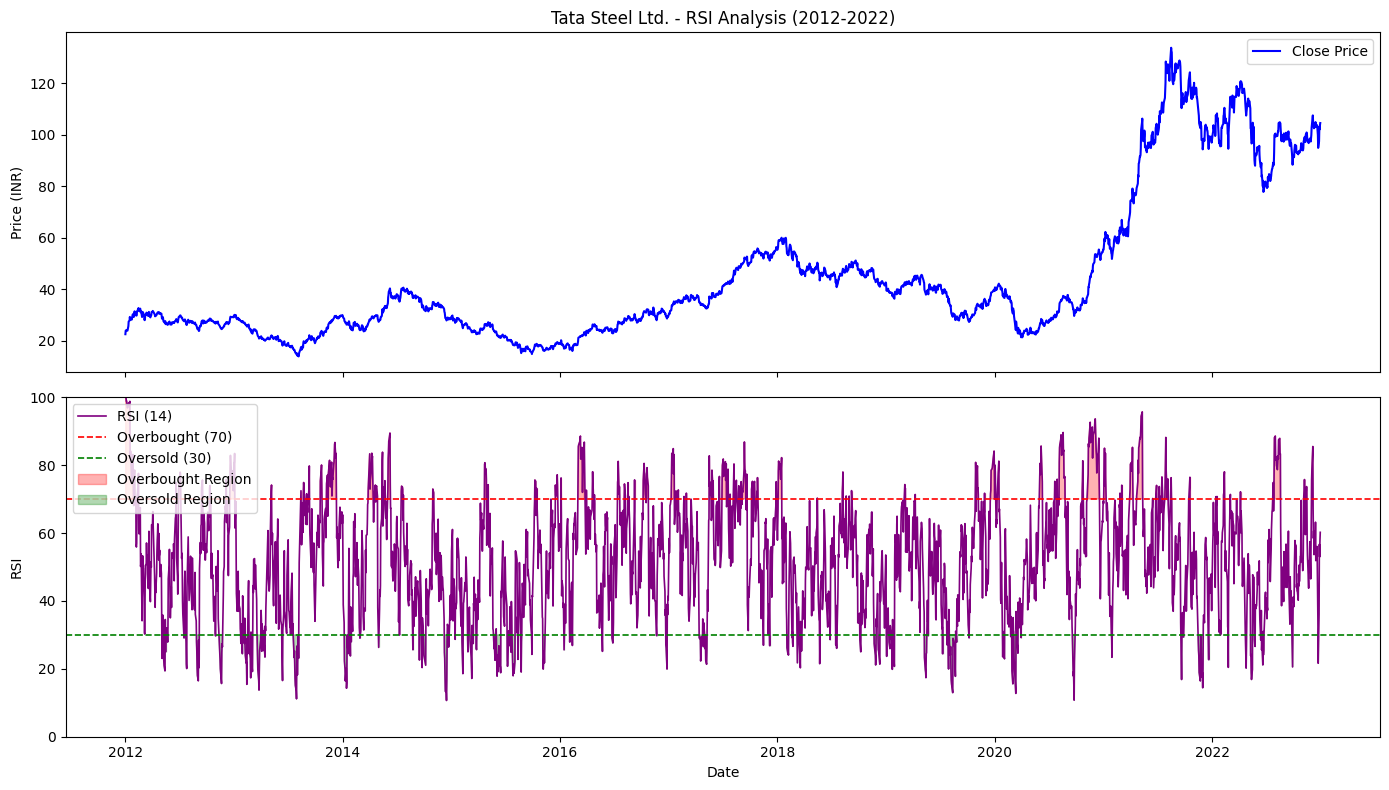

In [8]:
def plot_rsi(df, label, period=14):
    """
    Plot RSI for a stock with overbought/oversold regions.

    Parameters:
        df (pd.DataFrame): Stock data DataFrame
        label (str): Stock name for the title
        period (int): RSI period (default 14)
    """
    close = df['Close'].squeeze().astype(float)
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(span=period, adjust=False).mean()
    avg_loss = loss.ewm(span=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(df.index, close, label='Close Price', color='blue')
    ax1.set_title(f'{label} - RSI Analysis (2012-2022)')
    ax1.set_ylabel('Price (INR)')
    ax1.legend()

    ax2.plot(df.index, rsi, label=f'RSI ({period})', color='purple', linewidth=1.2)
    ax2.axhline(70, color='red', linestyle='--', linewidth=1.2, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle='--', linewidth=1.2, label='Oversold (30)')
    ax2.fill_between(df.index, rsi, 70, where=(rsi >= 70), alpha=0.3, color='red', label='Overbought Region')
    ax2.fill_between(df.index, rsi, 30, where=(rsi <= 30), alpha=0.3, color='green', label='Oversold Region')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot RSI for each stock
plot_rsi(mrf_data, 'MRF Ltd.')
plot_rsi(bse_data, 'BSE Ltd.')
plot_rsi(tata_steel_data, 'Tata Steel Ltd.')

### Summarize your analysis

In [9]:
"""
Summary of Technical Analysis: MRF Ltd., BSE Ltd., and Tata Steel Ltd. (2012-2022)

=== MRF Ltd. (MRF.NS) ===
- Closing Price Trend: MRF showed a strong long-term uptrend from 2012 to 2022, rising from
  approximately INR 5,000 to over INR 80,000, making it one of the most expensive stocks on Indian exchanges.
- SMA & EMA (5-day): The 5-day SMA and EMA closely tracked the closing price due to the short window.
  The EMA reacted faster to price changes, confirming MRF's consistent bullish momentum with occasional
  short-term corrections.
- MACD: The MACD line remained mostly above zero over the decade, with bullish crossovers (MACD crossing
  above the signal line) aligning with major price rallies (e.g., 2014-2015, 2017-2018). Bearish crossovers
  preceded brief corrective phases.
- RSI (14-day): MRF's RSI frequently entered overbought territory (>70) during strong bull phases, particularly
  during 2014-2015 and 2021-2022. Oversold dips (<30) were rare and short-lived, consistent with MRF's
  fundamentally strong business.

=== BSE Ltd. (BSE.NS) ===
- Closing Price Trend: BSE Ltd. exhibited a volatile but overall upward trend. The stock saw significant
  appreciation post-2017 listing and surged strongly in 2021-2022 due to booming capital market activity.
- SMA & EMA (5-day): The 5-day SMA and EMA moved closely with prices. The EMA was more responsive during
  sharp rallies in 2021, quickly adapting to the rapid price increases.
- MACD: MACD showed frequent crossovers, indicating BSE's relatively higher volatility compared to MRF.
  Bullish crossovers in 2020-2021 aligned with the post-COVID market recovery rally.
- RSI (14-day): RSI repeatedly hit overbought levels (>70) during the 2021 bull run, suggesting the stock
  was stretched at those highs. Brief oversold periods appeared during the 2020 COVID crash.

=== Tata Steel Ltd. (TATASTEEL.NS) ===
- Closing Price Trend: Tata Steel's price was highly cyclical, reflecting global steel demand cycles.
  The stock dropped significantly in 2015-2016 due to commodity headwinds, recovered strongly through
  2017-2018, corrected again in 2019, and then had a massive bull run in 2020-2022 driven by commodity supercycle.
- SMA & EMA (5-day): Due to higher cyclicality and volatility, the 5-day SMA and EMA crossed frequently.
  The EMA proved more useful in capturing momentum shifts during turnaround periods.
- MACD: The MACD showed clear bearish divergence in 2015-2016 and very strong bullish crossovers in
  2020-2021, perfectly timing the commodity-driven rally.
- RSI (14-day): Tata Steel saw deep oversold readings (<30) during the 2016 commodity downturn and the
  2020 COVID crash. Overbought readings (>70) dominated the 2021 commodity supercycle upswing.

=== Overall Comparison ===
- MRF is the most stable and consistently growing stock, suitable for long-term investors.
- BSE Ltd. offers high growth tied to capital market activity but with higher volatility.
- Tata Steel is the most cyclical, offering the highest potential returns but with significant downside risk.
- Across all three stocks, MACD and RSI effectively captured major turning points and momentum shifts.
- The 5-day SMA and EMA were useful for short-term momentum but are better supplemented with longer-period
  indicators for trend confirmation.
"""

"\nSummary of Technical Analysis: MRF Ltd., BSE Ltd., and Tata Steel Ltd. (2012-2022)\n\n=== MRF Ltd. (MRF.NS) ===\n- Closing Price Trend: MRF showed a strong long-term uptrend from 2012 to 2022, rising from\n  approximately INR 5,000 to over INR 80,000, making it one of the most expensive stocks on Indian exchanges.\n- SMA & EMA (5-day): The 5-day SMA and EMA closely tracked the closing price due to the short window.\n  The EMA reacted faster to price changes, confirming MRF's consistent bullish momentum with occasional\n  short-term corrections.\n- MACD: The MACD line remained mostly above zero over the decade, with bullish crossovers (MACD crossing\n  above the signal line) aligning with major price rallies (e.g., 2014-2015, 2017-2018). Bearish crossovers\n  preceded brief corrective phases.\n- RSI (14-day): MRF's RSI frequently entered overbought territory (>70) during strong bull phases, particularly\n  during 2014-2015 and 2021-2022. Oversold dips (<30) were rare and short-lived,